#### Perform ROC AUC Curve on the Customer Churn Dataset


#### Title:---

Customer Churn Prediction using ROC-AUC Curve Evaluation

#### Problem Statement:----

A telecomm company wants to predict whether the customer will leave the company (churn) or not 

The objective of this Customer Churn Project is to  :----

(a.)    To build a classification model

(b.)    To predict whether the customer will churn or not

(c.)    To evaluate the performance of the model using ROC-AUC Curve

(d.)    To compare multiple models

(e.)    To improve the decision making


####  Step 1:  Import  all the necessary libraries

In [5049]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection  import  train_test_split, GridSearchCV, StratifiedKFold
from    sklearn.preprocessing    import  StandardScaler
from    sklearn.pipeline         import  Pipeline
from    sklearn.linear_model     import  LogisticRegression
from    sklearn.tree             import  DecisionTreeClassifier
from    sklearn.ensemble         import  RandomForestClassifier
from    sklearn.metrics          import  accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

#### OBSERVATIONS:

(a.)    roc_curve ==================>  It is used to calculate the False Positive Rate and the True Positive Rate.

(b.)    roc_auc_score ==============>  

    (i.)    It is a metric that is used in the classification problem statement. 

    (ii.)   It is used espicially in binary classification problem statement.

    (iii.)  It determines how well the model seperates between class 0 and class 1.

#### Step 2:    Load the dataset

In [5050]:
#### read the dataset

df = pd.read_csv('Customer_Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### OBSERVATIONS:

1.  The above dataset explains whether the Customer will leave the company (churn) or not.

2.  The independent features in the dataset ranges from CustomerID ......... TotalCharges.

3.  The dependent feature in the dataset is the "Churn"

        (a.)    If the Customer leaves the company, then Churn is Yes

        (b.)    If the customer does not leave the company, then the Churn is No

#### Step 3:  Perform the Data Exploration

In [5051]:
#### display the first five rows of the dataset

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5052]:
#### display the last five rows of the dataset

df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5053]:
#### display the total length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 7043


In [5054]:
#### Shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (7043, 21)


In [5055]:
#### get the columns used in the dataset

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5056]:
#### get the information about all the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5057]:
#### get the descriptive summary statistics about all the numerical columns used in the dataset

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#### OBSERVATIONS:

1.  The above table explains about the statistical summary for each numerical column in the dataset.

In [5058]:
#### get the descriptive statistical summary for each categorical column in the dataset

df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


#### OBSERVATIONS:

1.  The above table explains about the statistical summary for each categorical column in the dataset.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [5059]:
#### To check for the NULL records in the dataset

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records used in the dataset.

In [5060]:
#### To check for the duplicate records used in the dataset

df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

In [5061]:
#### Remove Customer ID the unnecessary from the dataset

df.drop(columns='customerID',axis=1,inplace=True)

In [5062]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5063]:
##### Now again check for any NULL records in the revised dataset

df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the revised dataset

#### OBSERVATIONS:

1.  There are  duplicate records in the revised dataset after removing customer ID column from the dataset. So remove the duplicate records.

In [5064]:
#### Remove the duplicate records from the dataset

df.drop_duplicates(inplace=True)

In [5065]:
#### To again check for the duplicate records 

df[df.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [5066]:
#### Again display the total length of the revised dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 7021


#### OBSERVATIONS:

1.  The length of the dataset has reduced from 7043 to 7021 records after removing the CustomerID and the duplicate records from the dataset.

In [5067]:
#### Again display the shape of the revised dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (7021, 20)


#### OBSERVATIONS:

1.  The total number of columns has reduced from 21 to 20 after removing the unnecessary column "CustomerID" from the dataset.

2.  The total records of the dataset has reduced from 7043 to 7021 after removing the unnecessary column "CustomerID" and the duplicates from the dataset.

In [5068]:
##### Now again check for any NULL records in the revised dataset

df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the revised dataset

In [5069]:
#### To check for the duplicate records in the new dataset

df[df.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [5070]:
#### To check the data types for each column

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

In [5071]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5072]:
#### Convert the data type of "TotalCharges"  from object to  numeric

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [5073]:
#### To check the data types for each column

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

In [5074]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5075]:
x = ["gender","Partner","Dependents","PhoneService","MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract", "PaperlessBilling","PaymentMethod","Churn"]

from sklearn.preprocessing  import  LabelEncoder

### define the object for Label Encoder

label = LabelEncoder()

for i in x:
    df[i] = label.fit_transform(df[i])

In [5076]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


#### OBSERVATIONS:

1.  Label Encoding has been applied on every categorical columns in the dataset and all the categorical values have been converted into the numerical values.

2.  Now the dataset is completely ready for getting trained into the ML Model.

In [5077]:
#### To check for the NULL records in the revised dataset

df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

#### OBSERVATIONS:

1. The columns "TotalCharges" has 11 NULL records in the dataset. So replace it with the mean value of "TotalCharges" column.

In [5078]:
#### Find out the records in which total charges are NULL

null_charges = df[df["TotalCharges"].isnull()]

In [5079]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].mean())

In [5080]:
#### Again check for  the records in which total charges are NULL

df[df["TotalCharges"].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


#### OBSERVATIONS:

1. There are now no NULL records in the "TotalCharges" column.

In [5081]:
#### To check for the NULL records in the revised dataset

df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### OBSERVATIONS:

1.  There are now no NULL records present in the dataset.

#### Step 5: Perform Exploratory Data Analysis (EDA)

In [5082]:
#### get the information about all the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   int64  
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   int64  
 3   Dependents        7021 non-null   int64  
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   int64  
 6   MultipleLines     7021 non-null   int64  
 7   InternetService   7021 non-null   int64  
 8   OnlineSecurity    7021 non-null   int64  
 9   OnlineBackup      7021 non-null   int64  
 10  DeviceProtection  7021 non-null   int64  
 11  TechSupport       7021 non-null   int64  
 12  StreamingTV       7021 non-null   int64  
 13  StreamingMovies   7021 non-null   int64  
 14  Contract          7021 non-null   int64  
 15  PaperlessBilling  7021 non-null   int64  
 16  PaymentMethod     7021 non-null   int64  
 17  

#### OBSERVATIONS:

1.  All the columns are integer in nature except MonthlyCharges and TotalCharges.

In [5083]:
#### get the distribution on the Churn column

df['Churn'].value_counts()

Churn
0    5164
1    1857
Name: count, dtype: int64

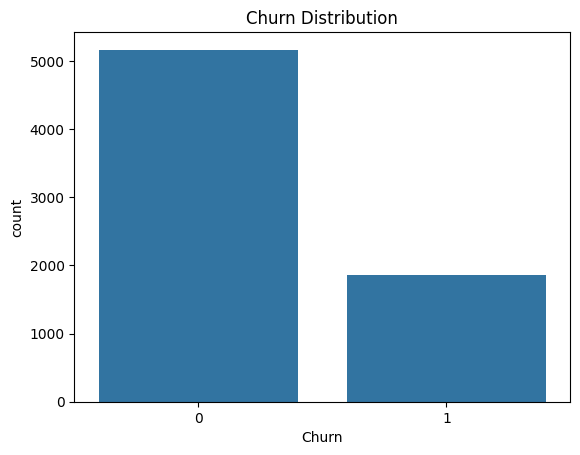

In [5084]:
#### perform the distribution on the "Churn" column

import  seaborn as sns 

sns.countplot(x = "Churn", data = df)

plt.title("Churn Distribution")

plt.show()

#### OBSERVATIONS:

1.  From the above graph distribution, we can see that the number of customers who will not leave the company or not churn are much higher in number than the customers who will leave the company.

In [5085]:
#### get the correlation for all the numeric columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   int64  
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   int64  
 3   Dependents        7021 non-null   int64  
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   int64  
 6   MultipleLines     7021 non-null   int64  
 7   InternetService   7021 non-null   int64  
 8   OnlineSecurity    7021 non-null   int64  
 9   OnlineBackup      7021 non-null   int64  
 10  DeviceProtection  7021 non-null   int64  
 11  TechSupport       7021 non-null   int64  
 12  StreamingTV       7021 non-null   int64  
 13  StreamingMovies   7021 non-null   int64  
 14  Contract          7021 non-null   int64  
 15  PaperlessBilling  7021 non-null   int64  
 16  PaymentMethod     7021 non-null   int64  
 17  

In [5086]:
df.corr()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
gender,1.000000,-0.001125,-0.001014,0.011081,0.006185,-0.006769,-0.005939,-0.001762,-0.015262,-0.012182,0.000449,-0.007045,-0.006461,-0.008781,0.000811,-0.011350,0.016304,-0.013158,0.000878,-0.008763
SeniorCitizen,-0.001125,1.000000,0.015553,-0.212115,0.015349,0.008909,0.145521,-0.031221,-0.128267,-0.013675,-0.021448,-0.151349,0.030704,0.047209,-0.143624,0.156196,-0.037320,0.219434,0.101626,0.151619
Partner,-0.001014,0.015553,1.000000,0.451659,0.377346,0.018728,0.139827,0.003667,0.150589,0.152518,0.165752,0.126422,0.136443,0.128635,0.293042,-0.015776,-0.152069,0.094301,0.316762,-0.149135
Dependents,0.011081,-0.212115,0.451659,1.000000,0.157603,-0.001092,-0.027083,0.046608,0.151984,0.090502,0.080015,0.133303,0.046140,0.020525,0.241912,-0.112220,-0.038185,-0.116191,0.062648,-0.163459
tenure,0.006185,0.015349,0.377346,0.157603,1.000000,0.009786,0.340458,-0.026847,0.325762,0.370824,0.371062,0.323197,0.288737,0.296225,0.670728,0.005053,-0.367827,0.245251,0.824158,-0.351508
PhoneService,-0.006769,0.008909,0.018728,-0.001092,0.009786,1.000000,-0.019554,0.387549,-0.015026,0.024439,0.004043,-0.018980,0.055807,0.044322,0.003101,0.016824,-0.005304,0.248984,0.114063,0.011323
MultipleLines,-0.005939,0.145521,0.139827,-0.027083,0.340458,-0.019554,1.000000,-0.106819,0.006599,0.116625,0.121633,0.010909,0.174225,0.180113,0.108553,0.164814,-0.174073,0.432246,0.451191,0.040175
InternetService,-0.001762,-0.031221,0.003667,0.046608,-0.026847,0.387549,-0.106819,1.000000,-0.029421,0.035736,0.044563,-0.027019,0.107508,0.098435,0.102456,-0.137056,0.082669,-0.320525,-0.173279,-0.047366
OnlineSecurity,-0.015262,-0.128267,0.150589,0.151984,0.325762,-0.015026,0.006599,-0.029421,1.000000,0.184211,0.175061,0.284255,0.043553,0.054847,0.374556,-0.157024,-0.096968,-0.053347,0.254301,-0.288505
OnlineBackup,-0.012182,-0.013675,0.152518,0.090502,0.370824,0.024439,0.116625,0.035736,0.184211,1.000000,0.186760,0.194841,0.146071,0.135587,0.280658,-0.012565,-0.124724,0.120391,0.375235,-0.194214


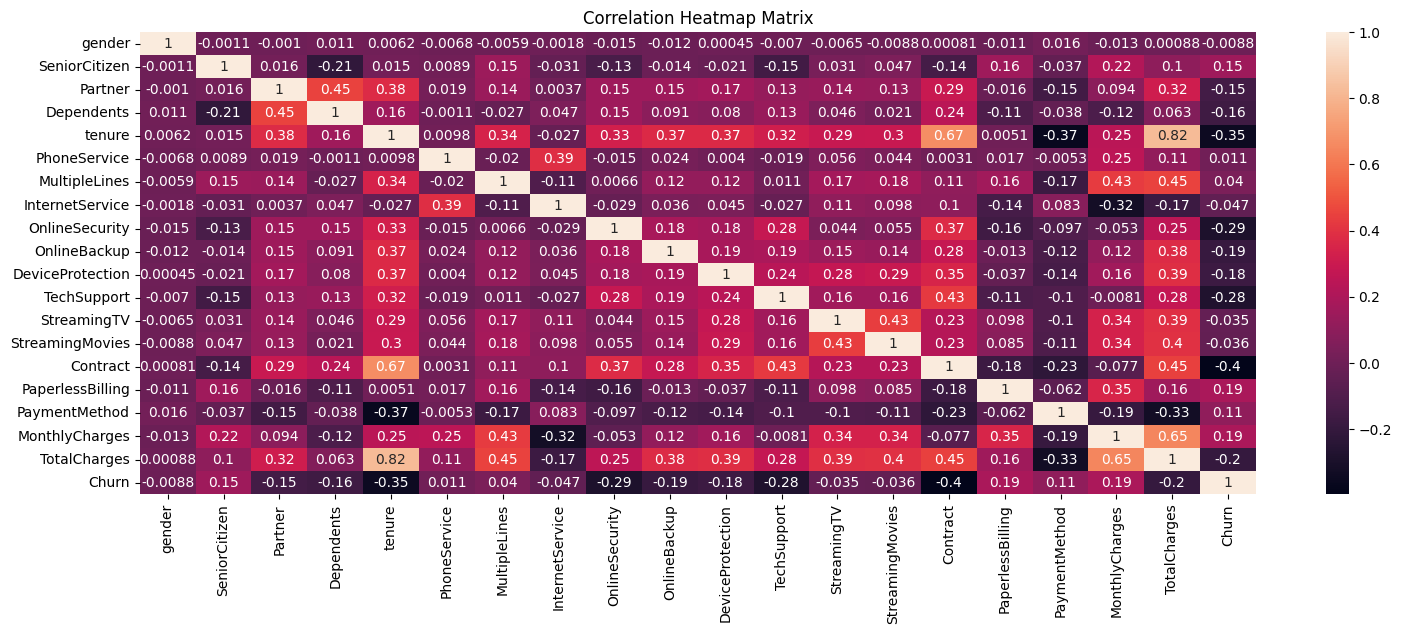

In [5087]:
#### Get the graphical representation for the correlation for all the numeric columns used in the dataset

plt.figure(figsize=(18,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Heatmap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above matrix depicts about the graphical representation for each column with every column used in the dataset.

#### Step 6: Divide the dataset into independent and dependent features

In [5088]:
#### independent features

X = df.drop(columns='Churn',axis=1)

print(X)

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0          0              0        1           0       1             0   
1          1              0        0           0      34             1   
2          1              0        0           0       2             1   
3          1              0        0           0      45             0   
4          0              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       1              0        1           1      24             1   
7039       0              0        1           1      72             1   
7040       0              0        1           1      11             0   
7041       1              1        1           0       4             1   
7042       1              0        0           0      66             1   

      MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0                 1                0     

In [5089]:
#### dependent features

Y = df['Churn']

print(Y)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7021, dtype: int64


#### Step 7: Divide the independent and dependent features into training and testing data

In [5090]:
from    sklearn.model_selection  import  train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42,stratify=Y)

In [5091]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2629,1,0,0,0,2,1,0,1,0,0,0,0,0,0,0,0,1,70.70,140.70
2650,0,0,0,0,15,1,2,1,2,0,2,0,0,0,0,1,1,84.35,1302.65
1418,1,0,1,1,67,1,2,1,0,2,0,0,0,2,0,1,0,89.55,6373.10
5774,1,0,0,0,5,1,0,0,0,2,0,2,0,2,0,1,0,65.60,339.90
2425,1,0,0,0,26,1,0,2,1,1,1,1,1,1,0,1,2,20.30,511.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6696,1,0,0,0,5,1,2,1,0,2,2,0,0,2,0,0,2,96.55,500.10
2094,0,0,0,0,18,1,0,2,1,1,1,1,1,1,0,0,3,19.65,391.70
4991,0,0,0,0,58,1,0,1,2,2,2,0,2,2,1,1,2,106.45,6145.85
6882,0,1,0,0,71,1,2,1,2,2,0,2,2,0,1,1,1,99.65,7181.25


In [5092]:
X_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
5627,1,1,1,0,7,1,2,1,0,0,0,0,0,0,0,1,2,74.85,485.25
6126,1,1,0,0,19,1,0,1,0,0,2,0,2,2,0,1,1,95.90,1777.90
2361,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,3,45.95,45.95
2201,0,0,0,0,36,1,0,0,2,2,2,2,2,2,1,0,0,85.85,3003.55
832,0,0,1,1,70,1,0,0,2,2,2,2,0,2,1,0,1,74.10,5222.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2310,1,0,0,0,72,0,1,0,2,2,2,2,2,2,2,1,0,63.70,4464.80
2685,0,0,1,0,72,1,2,1,2,2,2,0,2,0,2,0,0,100.65,7334.05
1104,1,0,0,0,42,1,0,2,1,1,1,1,1,1,1,1,3,19.55,839.40
5704,0,0,1,0,19,1,2,1,0,0,0,0,2,0,0,1,2,86.85,1564.40


In [5093]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (5616, 19)
Shape of the input testing  data is: (1405, 19)


In [5094]:
Y_train

2629    1
2650    0
1418    0
5774    0
2425    0
       ..
6696    0
2094    0
4991    1
6882    0
400     0
Name: Churn, Length: 5616, dtype: int64

In [5095]:
Y_test

5627    0
6126    1
2361    1
2201    0
832     0
       ..
2310    0
2685    0
1104    0
5704    0
5398    0
Name: Churn, Length: 1405, dtype: int64

In [5096]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (5616,)
Shape of the output testing  data is: (1405,)


#### Step 8: Perform Feature Scaling on the inputs

In [5097]:
from    sklearn.preprocessing   import  StandardScaler

####  create an object for Standard Scaler

sc = StandardScaler()

#### using the object for standard scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

In [5098]:
X_train_scaled

array([[ 1.00035619, -0.44031529, -0.97363795, ..., -0.53732926,
         0.19316451, -0.94709771],
       [-0.99964394, -0.44031529, -0.97363795, ..., -0.53732926,
         0.64735514, -0.4360294 ],
       [ 1.00035619, -0.44031529,  1.02707582, ..., -1.4762344 ,
         0.82038014,  1.79414084],
       ...,
       [-0.99964394, -0.44031529, -0.97363795, ...,  0.40157588,
         1.3827114 ,  1.69418793],
       [-0.99964394,  2.2710999 , -0.97363795, ..., -0.53732926,
         1.15644794,  2.1495949 ],
       [-0.99964394, -0.44031529, -0.97363795, ..., -1.4762344 ,
        -1.50214778, -0.73445863]])

In [5099]:
X_test_scaled = sc.transform(X_test)

In [5100]:
X_test_scaled

array([[ 1.00035619,  2.2710999 ,  1.02707582, ...,  0.40157588,
         0.33125177, -0.79555196],
       [ 1.00035619,  2.2710999 , -0.97363795, ..., -0.53732926,
         1.03167029, -0.22699699],
       [-0.99964394, -0.44031529, -0.97363795, ...,  1.34048102,
        -0.63036796, -0.98877224],
       ...,
       [ 1.00035619, -0.44031529, -0.97363795, ...,  1.34048102,
        -1.50880259, -0.63978377],
       [-0.99964394, -0.44031529,  1.02707582, ...,  0.40157588,
         0.73054024, -0.32090213],
       [ 1.00035619, -0.44031529, -0.97363795, ...,  1.34048102,
        -1.50214778, -0.99169716]])

#### OBSERVATIONS:

1.  All the input features have been transformed in the same scale range of inputs between -1 to 1.

#### Step 9: Train the Logistic Regression Model

In [5101]:
from  sklearn.linear_model  import  LogisticRegression

#### create an object for Logistic Regression

log = LogisticRegression(max_iter=1000)

#### using the object for Logistic Regression, train the model

log.fit(X_train_scaled, Y_train)

LogisticRegression(max_iter=1000)

#### OBSERVATIONS:

1.  The object for Logistic Regression model has been initialized.

2.  The model has been trained with the hep of the training data.

#### Step 10:   Predict the model

In [5102]:
Y_pred = log.predict(X_test_scaled)

In [5103]:
Y_pred

array([1, 1, 0, ..., 0, 1, 0])

#### Step 11: Perform the Classification Evaluation Metrics

In [5104]:
print("===========================Accuracy score==================================================")

ac = accuracy_score(Y_test, Y_pred)*100.0
print("Accuracy score of the model is:", ac)

===========================Accuracy score==================================================
Accuracy score of the model is: 79.9288256227758


===========================Confusion matrix==================================================


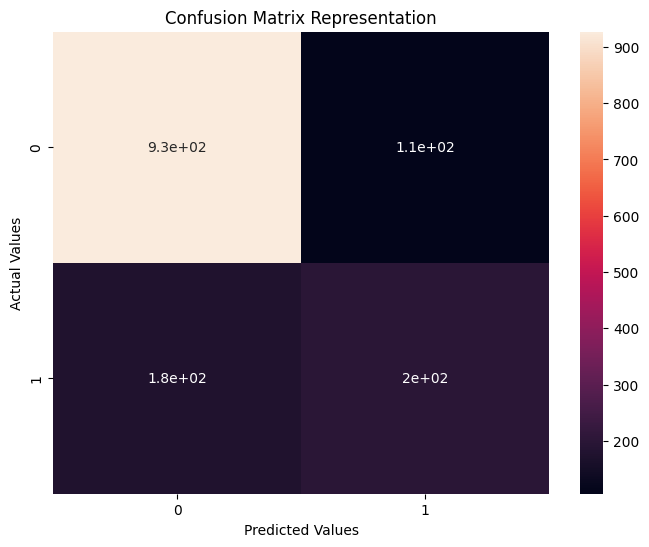

In [5105]:
print("===========================Confusion matrix==================================================")

plt.figure(figsize=(8,6))
cm = confusion_matrix(Y_test, Y_pred)

#### perform the graphical representation for the confusion matrix in the graph
sns.heatmap(cm, annot=True)

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix Representation")
plt.show()

In [5106]:
print("===========================Classification report==================================================")

cr = classification_report(Y_test, Y_pred)

print(cr)

===========================Classification report==================================================
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.53      0.58       372

    accuracy                           0.80      1405
   macro avg       0.74      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405



In [5107]:
print("===========================Precision score==================================================")

pr = precision_score(Y_test, Y_pred)

print(pr)

===========================Precision score==================================================
0.6490066225165563


In [5108]:
print("===========================Recall score==================================================")

re = recall_score(Y_test, Y_pred)

print(re)

===========================Recall score==================================================
0.5268817204301075


In [5109]:
print("===========================F1 score==================================================")

f1 = f1_score(Y_test, Y_pred)

print(f1)

===========================F1 score==================================================
0.5816023738872403


#### roc_curve

    (a.)    roc_curve is a metrics that is used to evaluate the performance of the classification algorithm.

    (b.)    It is used to deal with the binary values

    (c.)    It depicts about full ROC curve data points

    (d.)    It explains the relationship between the False Positive Rate and the True Positive Rate


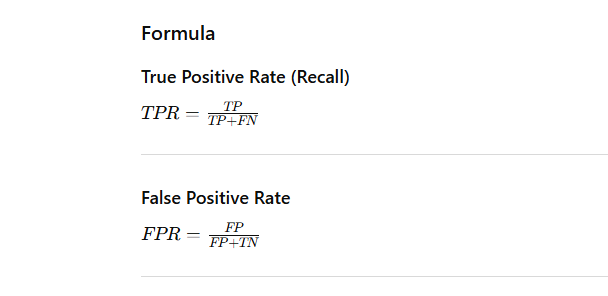

In [5110]:
Y_pred_proba = log.predict_proba(X_test_scaled)[:,1]

In [5111]:
#### Calculate the ROC Score

rocaucscore = roc_auc_score(Y_test, Y_pred_proba)

print("ROC AUC Score of the model is:", rocaucscore)

ROC AUC Score of the model is: 0.8387552176040137


#### OBSERVATIONS:

1.  The ROC AUC Score is a single numerical vaue that explains how well the model seperates between the datas of Class 0 and Class 1 

2.  It easily seperates the datas of two different categories.

3.  This model with the ROC AUC Score of 0.8387 explains that the model has 83.87 % of the ability to determine correctly whether the customer can churn or not.

False Positive Rate  is: [0.         0.         0.         0.00193611 0.00193611 0.00580833
 0.00580833 0.00677638 0.00677638 0.00774443 0.00774443 0.00871249
 0.00871249 0.00968054 0.00968054 0.0106486  0.0106486  0.01161665
 0.01161665 0.0125847  0.0125847  0.01355276 0.01355276 0.01452081
 0.01452081 0.01742498 0.01742498 0.01839303 0.01839303 0.01936108
 0.01936108 0.02032914 0.02032914 0.02129719 0.02129719 0.02226525
 0.02226525 0.0232333  0.0232333  0.02516941 0.02516941 0.02613746
 0.02613746 0.02807357 0.02807357 0.02904163 0.02904163 0.03000968
 0.03000968 0.03194579 0.03194579 0.03291384 0.03291384 0.03581801
 0.03581801 0.03969022 0.03969022 0.04065828 0.04065828 0.04259439
 0.04259439 0.04356244 0.04356244 0.04453049 0.04453049 0.04549855
 0.04549855 0.04743466 0.04743466 0.04840271 0.04840271 0.04937076
 0.04937076 0.05130687 0.05130687 0.05227493 0.05227493 0.05324298
 0.05324298 0.05421104 0.05421104 0.05517909 0.05517909 0.05614714
 0.05614714 0.0571152  0.0571152  0.0

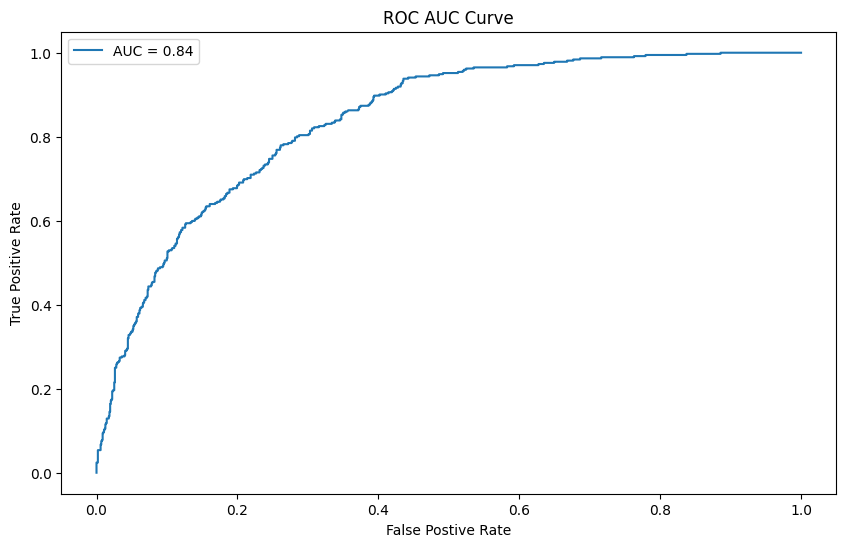

In [5112]:
from    sklearn.metrics     import  roc_curve

fpr,    tpr, thresholds = roc_curve(Y_test, Y_pred_proba)

print("False Positive Rate  is:", fpr)

print("True Positive Rate is:", tpr)


#### Plot the ROC Curve

plt.figure(figsize=(10,6))

plt.plot(fpr, tpr, label=f"AUC = {rocaucscore:.2f}")
plt.xlabel("False Postive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC AUC Curve")
plt.legend()
plt.show()

#### OBSERVATIONS:

1.  predict_proba returns the probability for each and every class.

#### OBSERVATIONS:

1.  The above graph is a ROC Curve (Receiver Operating Characteristics) Curve.

2.  This graph explains  the relationship between the False Positive Rate vs True Positive Rate.

#### Step 12: Train the Decison Tree Classifier Model

In [5113]:
from sklearn.tree  import  DecisionTreeClassifier

#### create an object for Decision tree classifier model

dec = DecisionTreeClassifier(max_depth=5)


#### using the object for Decision tree classifier, train the model

dec.fit(X_train_scaled, Y_train)

DecisionTreeClassifier(max_depth=5)

#### Step 13: Predict the model

In [5114]:
Y_pred_dec = dec.predict(X_test_scaled)

In [5115]:
Y_pred_dec

array([1, 0, 1, ..., 0, 0, 0])

#### Step 14: Perform the Classification Evaluation Metrics

In [5116]:
print("===========================Accuracy score==================================================")

acdec = accuracy_score(Y_test, Y_pred_dec)*100.0
print("Accuracy score of the model is:", acdec)

===========================Accuracy score==================================================
Accuracy score of the model is: 78.64768683274022


===========================Confusion matrix==================================================


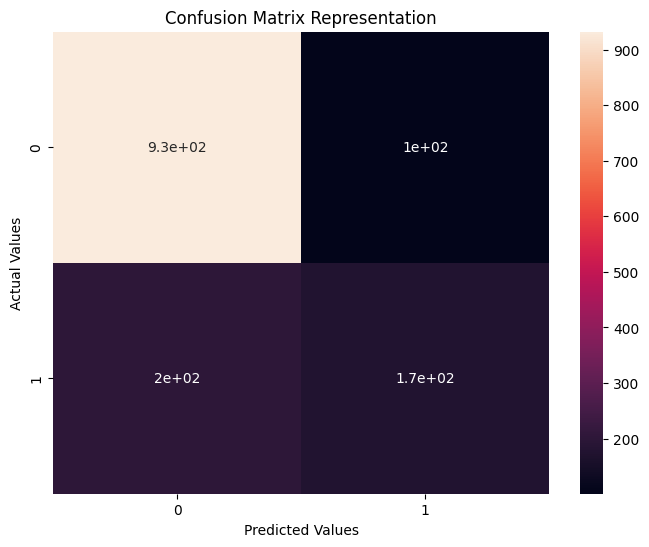

In [5117]:
print("===========================Confusion matrix==================================================")

plt.figure(figsize=(8,6))
cmdec = confusion_matrix(Y_test, Y_pred_dec)

#### perform the graphical representation for the confusion matrix in the graph
sns.heatmap(cmdec, annot=True)

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix Representation")
plt.show()

In [5118]:
print("===========================Classification report==================================================")

crdec = classification_report(Y_test, Y_pred_dec)

print(crdec)

===========================Classification report==================================================
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       372

    accuracy                           0.79      1405
   macro avg       0.73      0.68      0.70      1405
weighted avg       0.77      0.79      0.78      1405



In [5119]:
print("===========================Precision score==================================================")

prdec = precision_score(Y_test, Y_pred_dec)

print(prdec)

===========================Precision score==================================================
0.6313868613138686


In [5120]:
print("===========================Recall score==================================================")

redec = recall_score(Y_test, Y_pred_dec)

print(redec)

===========================Recall score==================================================
0.4650537634408602


In [5121]:
print("===========================F1 score==================================================")

f1dec = f1_score(Y_test, Y_pred_dec)

print(f1dec)

===========================F1 score==================================================
0.5356037151702786


#### roc_curve

    (a.)    roc_curve is a metrics that is used to evaluate the performance of the classification algorithm.

    (b.)    It is used to deal with the binary values

    (c.)    It depicts about full ROC curve data points

    (d.)    It explains the relationship between the False Positive Rate and the True Positive Rate


![image.png](attachment:image.png)

In [5122]:
#### Calculate the ROC AUC Score

Y_pred_proba_dec = dec.predict_proba(X_test_scaled)[:,1]

In [5123]:
#### Calculate the ROC Score

rocaucscore = roc_auc_score(Y_test, Y_pred_proba_dec)

print("ROC AUC Score of the model is:", )

ROC AUC Score of the model is:


#### OBSERVATIONS:

1.  The ROC AUC Score is a single numerical vaue that explains how well the model seperates between the datas of Class 0 and Class 1 

2.  It easily seperates the datas of two different categories.

3.  This model with the ROC AUC Score of 0.8234 explains that the model has 82.34 % of the ability to determine correctly whether the customer can churn or not.

False Positive Rate  is: [0.         0.00290416 0.00580833 0.0125847  0.03775411 0.03872217
 0.06389158 0.09777348 0.18489835 0.20909971 0.23814134 0.24588577
 0.32333011 0.33688287 0.34656341 0.41045499 0.43562439 0.4714424
 0.53339787 0.57986447 0.63020329 0.66505324 0.7124879  0.79574056
 0.80154889 0.99903195 1.        ]
True Positive Rate is: [0.         0.00268817 0.09408602 0.11290323 0.25268817 0.26075269
 0.37096774 0.46505376 0.66129032 0.70698925 0.72311828 0.73655914
 0.80107527 0.81451613 0.81989247 0.87365591 0.88709677 0.90860215
 0.94086022 0.96505376 0.97580645 0.97580645 0.97849462 0.98655914
 0.98655914 0.99731183 1.        ]


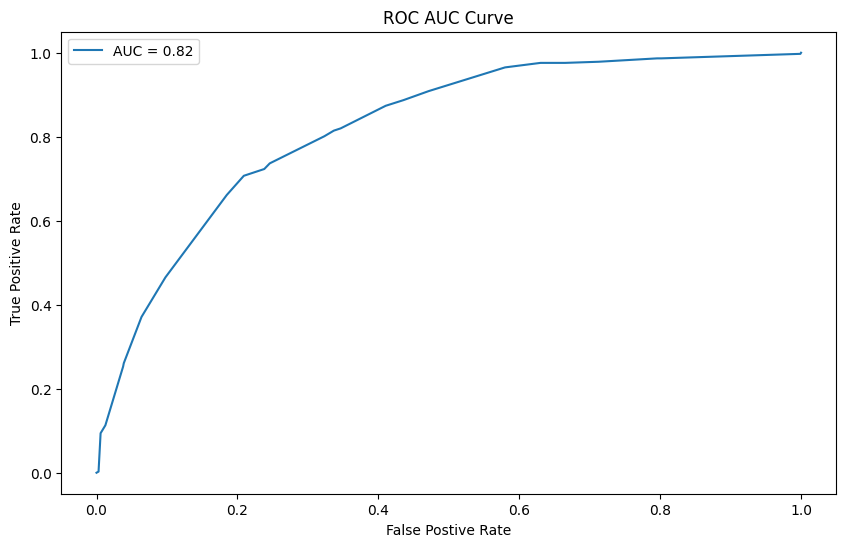

In [5124]:
from    sklearn.metrics     import  roc_curve

fpr,    tpr, thresholds = roc_curve(Y_test, Y_pred_proba_dec)

print("False Positive Rate  is:", fpr)

print("True Positive Rate is:", tpr)


#### Plot the ROC Curve

plt.figure(figsize=(10,6))

plt.plot(fpr, tpr, label=f"AUC = {rocaucscore:.2f}")
plt.xlabel("False Postive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC AUC Curve")
plt.legend()
plt.show()

#### OBSERVATIONS:

1.  The above graph is a ROC Curve (Receiver Operating Characteristics) Curve.

2.  This graph explains  the relationship between the False Positive Rate vs True Positive Rate.

####    Random Forest Classifier

In [5125]:
from    sklearn.ensemble  import  RandomForestClassifier


#### create an object for Random Forest Classifier

rcf = RandomForestClassifier(n_estimators=100)

#### using the object for Random Forest Classifier, train the  model

rcf.fit(X_train_scaled, Y_train)

RandomForestClassifier()

In [5126]:
#### predict the model

Y_pred_rcf = rcf.predict(X_test_scaled)

In [5127]:
Y_pred_rcf

array([1, 1, 1, ..., 0, 0, 0])

In [5128]:
#### Evaluate the Classification Metrics

print("==============================accuracy score=========================================")

acrcf = accuracy_score(Y_test, Y_pred_rcf)*100.0

print("Accuracy of the model is:", acrcf)

==============================accuracy score=========================================
Accuracy of the model is: 77.72241992882563


==============================confusion matrix=========================================
Confusion matrix of the model is: [[928 105]
 [208 164]]


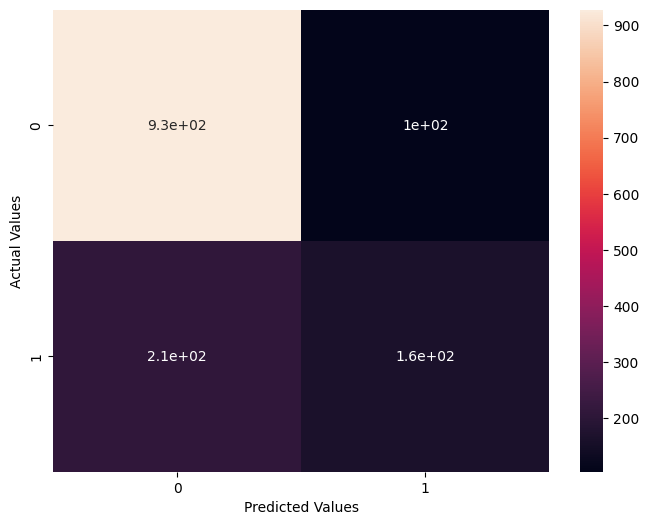

In [5129]:
print("==============================confusion matrix=========================================")

cmrcf = confusion_matrix(Y_test, Y_pred_rcf)

print("Confusion matrix of the model is:", cmrcf)


plt.figure(figsize=(8,6))
sns.heatmap(cmrcf, annot=True)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

In [5130]:
print("==============================classification report=========================================")

crrcf = classification_report(Y_test, Y_pred_rcf)

print("Classification report of the model is:", crrcf)

==============================classification report=========================================
Classification report of the model is:               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.61      0.44      0.51       372

    accuracy                           0.78      1405
   macro avg       0.71      0.67      0.68      1405
weighted avg       0.76      0.78      0.76      1405



In [5131]:
print("==============================precision score=========================================")

prrcf = precision_score(Y_test, Y_pred_rcf)

print("precision score of the model is:", prrcf)

==============================precision score=========================================
precision score of the model is: 0.6096654275092936


In [5132]:
print("==============================recall score=========================================")

rercf = recall_score(Y_test, Y_pred_rcf)

print("recall score of the model is:", rercf)

==============================recall score=========================================
recall score of the model is: 0.44086021505376344


In [5133]:
print("==============================f1 score=========================================")

f1rcf = f1_score(Y_test, Y_pred_rcf)

print("F1 score of the model is:", f1rcf)

==============================f1 score=========================================
F1 score of the model is: 0.5117004680187207


#### roc_curve

    (a.)    roc_curve is a metrics that is used to evaluate the performance of the classification algorithm.

    (b.)    It is used to deal with the binary values

    (c.)    It depicts about full ROC curve data points

    (d.)    It explains the relationship between the False Positive Rate and the True Positive Rate


![image.png](attachment:image.png)

In [5134]:
#### Calculate the roc auc score

Y_pred_proba_rcf = rcf.predict_proba(X_test_scaled)[:,1]

print(Y_pred_proba_rcf)

[0.72  0.56  0.625 ... 0.02  0.44  0.08 ]


In [5135]:
rocaucscorercf = roc_auc_score(Y_test, Y_pred_proba_rcf)


print("ROC AUC Score of the model is:", rocaucscorercf)

ROC AUC Score of the model is: 0.8156169003528715


#### OBSERVATIONS:

1.  The ROC AUC Score is a single numerical vaue that explains how well the model seperates between the datas of Class 0 and Class 1 

2.  It easily seperates the datas of two different categories.

3.  This model with the ROC AUC Score of 0.8124 explains that the model has 81.83 % of the ability to determine correctly whether the customer can churn or not.

False Positive Rate is: [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 9.68054211e-04 9.68054211e-04 1.93610842e-03 1.93610842e-03
 1.93610842e-03 1.93610842e-03 2.90416263e-03 2.90416263e-03
 3.87221684e-03 3.87221684e-03 5.80832527e-03 5.80832527e-03
 6.77637948e-03 8.71248790e-03 1.25847047e-02 1.25847047e-02
 1.45208132e-02 1.45208132e-02 1.74249758e-02 1.93610842e-02
 1.93610842e-02 1.93610842e-02 1.93610842e-02 2.22652469e-02
 2.32333011e-02 2.61374637e-02 2.61374637e-02 2.90416263e-02
 2.90416263e-02 3.00096805e-02 3.00096805e-02 3.09777348e-02
 3.19457890e-02 3.67860600e-02 4.06582769e-02 4.25943853e-02
 4.35624395e-02 4.84027106e-02 4.93707648e-02 4.93707648e-02
 5.22749274e-02 5.22749274e-02 5.61471442e-02 5.80832527e-02
 6.38915779e-02 6.58276864e-02 6.77637948e-02 7.06679574e-02
 7.55082285e-02 7.93804453e-02 8.80929332e-02 9.09970958e-02
 9.58373669e-02 1.00677638e-01 1.01645692e-01 1.03581801e-01
 1.04549855e-01 1.10358180e-01 1.17134560e-01 1.21006776e-01


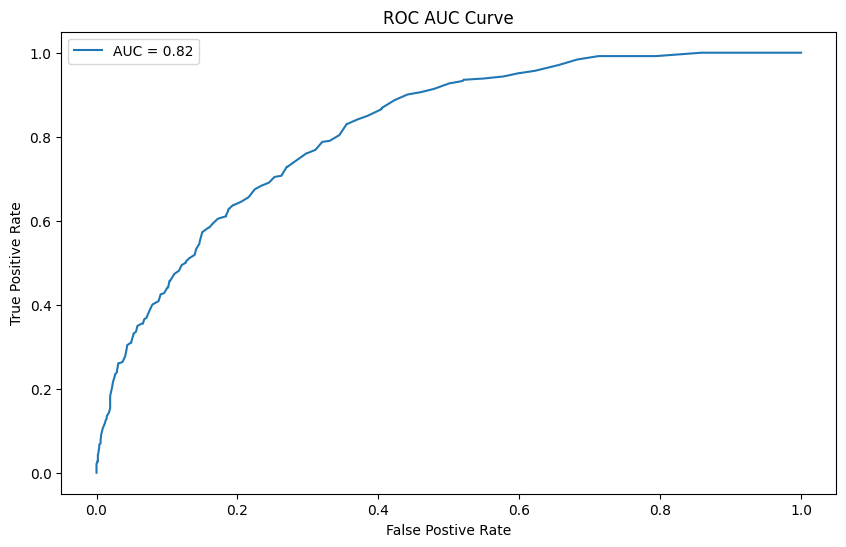

In [5136]:
#### Calculate the roc curve

from  sklearn.metrics  import  roc_curve

fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_proba_rcf)


print("False Positive Rate is:", fpr)

print("True Positive Rate is:", tpr)


#### Plot the ROC Curve

plt.figure(figsize=(10,6))

plt.plot(fpr, tpr, label=f"AUC = {rocaucscorercf:.2f}")
plt.xlabel("False Postive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC AUC Curve")
plt.legend()
plt.show()

#### OBSERVATIONS:

1.  The above graph is a ROC Curve (Receiver Operating Characteristics) Curve.

2.  This graph explains  the relationship between the False Positive Rate vs True Positive Rate.

#### Conclusions:--

(a.)  The ROC AUC Score of Logistic Regression = 83.87

(b.)  The ROC AUC Score of Decision Tree       = 82.34

(c.)  The ROC AUC Score of Random   Forest     = 81.51


So the  Logistic Regression > Decision Tree > Random Forest in terms of the ROC AUC Score

So the Logistic Regression Model is the best performing model that has the ability to determine correctly whether the customer will leae the bank or not. 